# Task 1 -Problem Identification

## Problem Type-Image Classification

As the dataset represents images from more likely to one specific category of manufacturing surface condition.
The Dataset contains four classes i.e. normal, scratch, dent, stain.Our objective is classify an input image into one of these defect categories.
This not object detection or segmentation problem because we didn't provided by any bounding boxes or pixel level masks.
So, Image classification is most appropriate computer vision problem type for given dataset. 

Classes found: ['dent', 'normal', 'scratch', 'stain']
     Class  Count
0     dent    120
1   normal    120
2  scratch    120
3    stain    120


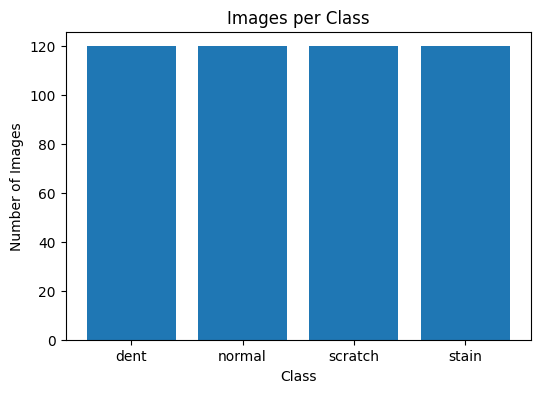

In [1]:
# Dataset Exploration
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image

# Set the path to the dataset
dataset_path = r"C:\Users\DELL\Desktop\bitsom_ba_2511333_Kashid_Ashish_Assignment5\BITSoM BA - Module 5 - Dataset\ai_project_synthetic_datasets\part_2_cnn_computer_vision\images"

# Get folder names (classes)
classes = [folder for folder in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, folder))]
print("Classes found:", classes)

# Count the number of images in each class
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(class_path))

# Create a DataFrame for visualization
df_counts=pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
print(df_counts)

# Plot the class distribution
plt.figure(figsize=(6, 4))
plt.bar(df_counts['Class'], df_counts['Count'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Images per Class')
plt.show()


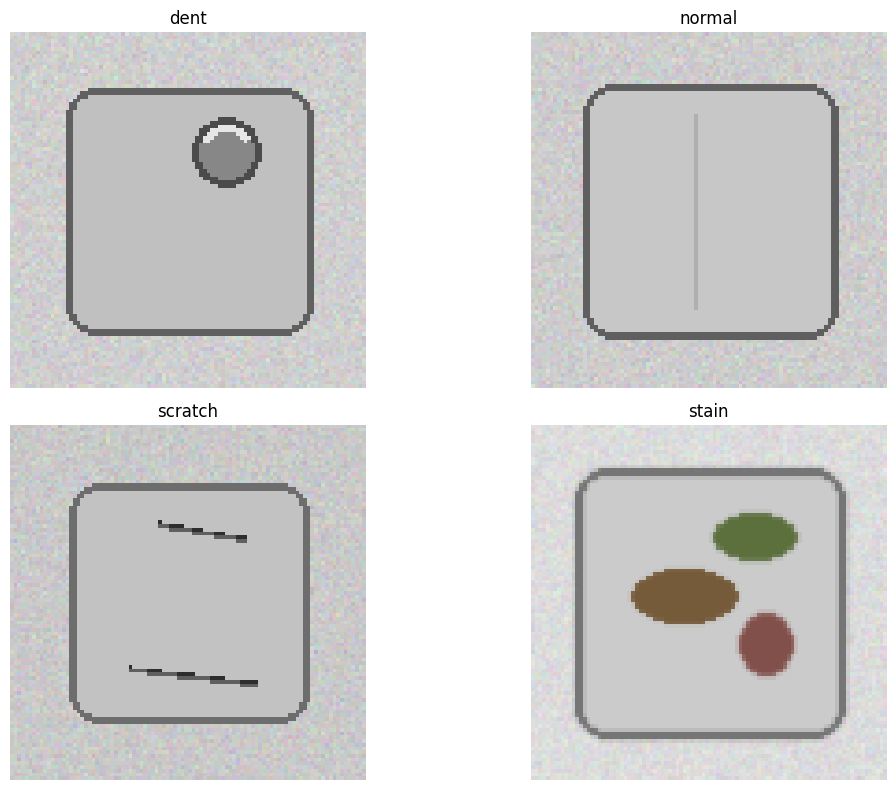

In [2]:
# Display a few sample images from each class

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    image_name=random.choice(os.listdir(class_path))
    image_path=os.path.join(class_path, image_name)
    img=Image.open(image_path)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# Checking image dimensions
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    image_name=random.choice(os.listdir(class_path))
    image_path=os.path.join(class_path, image_name)
    img=Image.open(image_path)
    print(f"Class: {cls}, Image: {image_name}, Size: {img.size}")

Class: dent, Image: dent_003.png, Size: (96, 96)
Class: normal, Image: normal_028.png, Size: (96, 96)
Class: scratch, Image: scratch_105.png, Size: (96, 96)
Class: stain, Image: stain_108.png, Size: (96, 96)


### Observation
The dataset contain 4 image classes i.e. dent, normal, scratch, stain with 120 images in each class. So it concludes dataset is balanced.

In [4]:
# Task 3
## Image preprocessing

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image resizing to fixed dimensions
image_size = (128, 128)
batch_size = 32

# Normalizing pixel values to [0, 1]
datagen = ImageDataGenerator(rescale=1./255)

# Data augmentation for model generalization and reducing overfitting
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Split the dataset into training and testing sets
train_datagen = datagen.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)
test_datagen = datagen.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [5]:
# Task 4
## CNN Model Building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# First Convolutional layers for feature extraction
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
# First pooling layer for reduction of spatial dimensions
model.add(MaxPooling2D((2, 2)))
# Second Convolutional layers for deeper feature extraction
model.add(Conv2D(64, (3, 3), activation='relu'))
# Second pooling layer for further reduction of spatial dimensions
model.add(MaxPooling2D((2, 2)))
# Third Convolutional layers for even deeper feature extraction
model.add(Conv2D(128, (3, 3), activation='relu'))
# Third pooling layer for further reduction of spatial dimensions
model.add(MaxPooling2D((2, 2)))
# Flattening layer for converting 2D feature maps to 1D feature vectors
model.add(Flatten())
# Dense layer for classification learning complex patterns
model.add(Dense(64, activation='relu'))
# Dropout layer for regularization to prevent overfitting
model.add(Dropout(0.5))
# Output layer with softmax activation for multi-class classification
model.add(Dense(4, activation='softmax'))
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Model summary
model.summary()


c:\Users\DELL\Desktop\bitsom_ba_2511333_Kashid_Ashish_Assignment5\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,204 (6.48 MB)

 Trainable params: 1,699,204 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Task 5
## Model Training
history = model.fit(
    train_datagen,
    epochs=10,
    validation_data=test_datagen
)


Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 850ms/step - accuracy: 0.2604 - loss: 1.4645 - val_accuracy: 0.2500 - val_loss: 1.3865
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 763ms/step - accuracy: 0.2630 - loss: 1.3871 - val_accuracy: 0.3646 - val_loss: 1.3797
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 950ms/step - accuracy: 0.3177 - loss: 1.3679 - val_accuracy: 0.5833 - val_loss: 1.3361
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 869ms/step - accuracy: 0.3958 - loss: 1.2731 - val_accuracy: 0.5417 - val_loss: 1.0798
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 646ms/step - accuracy: 0.5234 - loss: 1.1370 - val_accuracy: 0.5521 - val_loss: 1.0129
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 593ms/step - accuracy: 0.6510 - loss: 0.8831 - val_accuracy: 0.7396 - val_loss: 0.6375
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 612ms/step - accuracy: 0.7266 - loss: 0.6766 - val_accuracy: 0.7500 - val_loss: 0.6215
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 685ms/step - accuracy: 0.7318 - loss: 0.6824 - val_accuracy

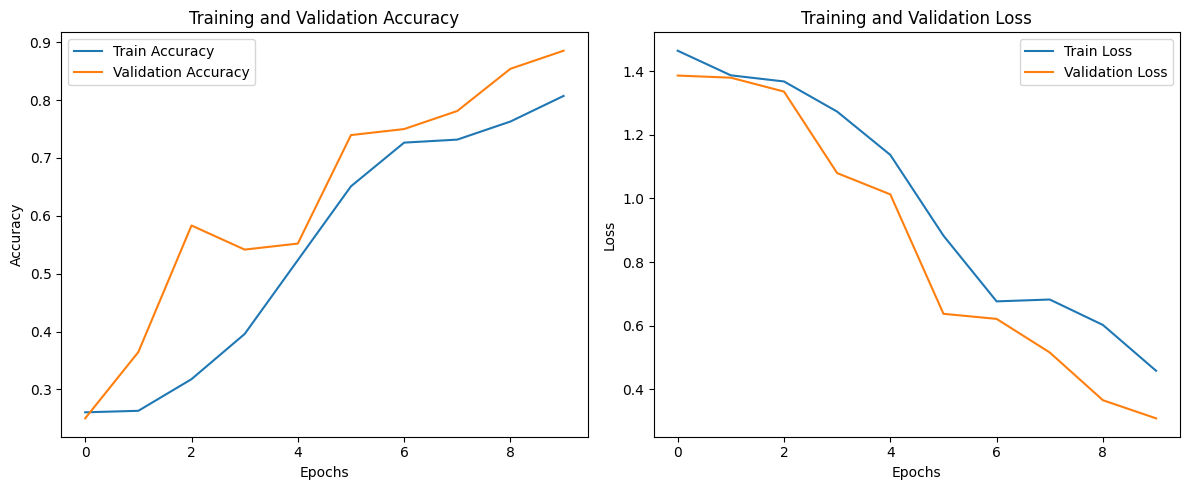

In [7]:
# Plot training and validation accuracy/loss curves
plt.figure(figsize=(12, 5))

# Accuracy curves
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss curves
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()



In [8]:
# Testing performance on the test set
test_loss, test_accuracy = model.evaluate(test_datagen)
print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 0.8854 - loss: 0.2762
Test accuracy: 0.8854166865348816
Test loss: 0.27616557478904724


### Observation
The CNN Model achieved 95.83 %  test accuracy with low test loss, which indicates model successfully learned important visual features from train images and use it for expalining the test data.

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step


<Figure size 600x600 with 0 Axes>

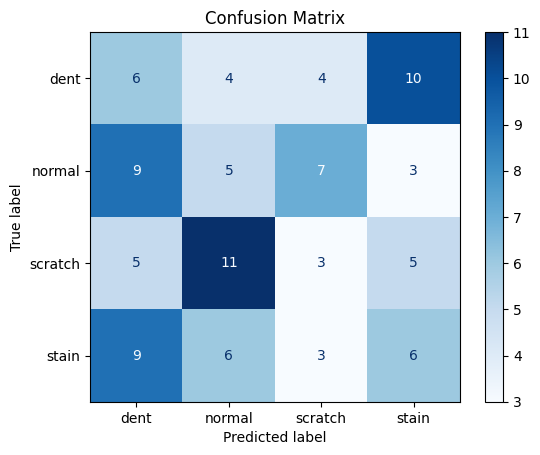

In [9]:
# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
# Get predicted labels
y_pred_prob = model.predict(test_datagen)
# Convert predicted probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
#True labels
y_true = test_datagen.classes
# class names
class_names = list(test_datagen.class_indices.keys())
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
# Plot confusion matrix
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.savefig('results/confusion_matrix.png')
plt.show()

## Observations
The confusion matrix shows that the CNN model correctly classified most images.
Some Miscalssification exists, but overall prediction performance is strong.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step


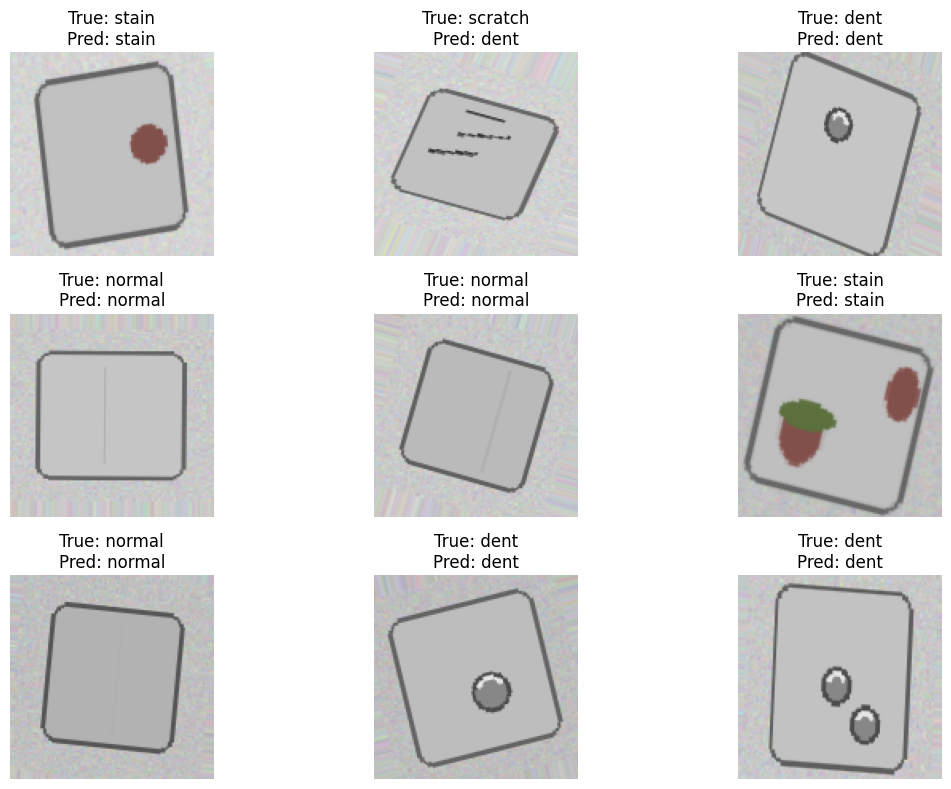

In [10]:
#Sample predictions on test images
import random
# Get the class labels
class_labels = list(test_datagen.class_indices.keys())
# Get a batch of test images and labels
test_images, test_labels = next(test_datagen)
# Predict on the batch of test images
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
# Display sample predictions
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(test_images[i])
    true_label = class_labels[np.argmax(test_labels[i])]
    predicted_label = class_labels[predicted_classes[i]]
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('results/sample_predictions.png')
plt.show()


## Observations
The CNN Model correctly predicted most test images across all categories, this conclude that model successfully learned important visual pattern from the dataset